# Online Retail Customer Analytics & Segmentation

## 📌 Project Overview
This project provides a comprehensive end-to-end analysis of an Online Retail dataset. The goal is to transform raw transaction data into actionable business intelligence using data cleaning, exploratory data analysis (EDA), time-series forecasting, and advanced customer segmentation techniques.

## 🛠️ Technical Stack
- **Data Manipulation:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **Analysis:** `datetime` for cohort logic and RFM modeling

## 🚀 Key Features

### 1. Data Cleaning & Preprocessing
- Handled missing values (specifically missing Customer IDs).
- Filtered out transaction cancellations and negative quantities to ensure revenue accuracy.
- Corrected data types for date-time analysis.

### 2. Exploratory Data Analysis (EDA)
- Identified top-performing countries by total revenue.
- Analyzed product popularity to identify high-volume inventory items.
- Visualized monthly revenue trends to identify seasonal patterns.

### 3. Time-Series Correction
- Identified and removed incomplete data periods (e.g., partial final months) to prevent misleading 'crashes' in sales charts.

### 4. Customer Retention (Cohort Analysis)
- Created a cohort matrix to track customer lifecycle.
- Visualized retention rates via a heatmap to show what percentage of customers return month-over-month.

### 5. RFM Segmentation
- **Recency:** Days since the last purchase.
- **Frequency:** Total number of distinct transactions.
- **Monetary:** Total revenue generated per customer.
- **Segmentation:** Classified customers into 10 actionable categories including *Champions*, *Loyal Customers*, *At Risk*, and *Hibernating* using quintile scoring.

## 📊 Business Insights
- Identified the core 'Champion' group contributing to the majority of revenue.
- Highlighted segments requiring re-engagement campaigns (e.g., 'At Risk' customers).
- Provided a snapshot of the business's health through retention metrics.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed the typo from read_cs to read_csv
df = pd.read_csv('online_retail_II.csv')
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. Data Cleaning and Preprocessing
We'll check for null values and data types to ensure the dataset is ready for analysis.

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Basic info about data types and memory usage
print("\nDataFrame Info:")
df.info()

# Convert InvoiceDate to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows with missing Customer IDs for a cleaner customer-centric analysis
df_cleaned = df.dropna(subset=['Customer ID'])

# Filter out cancellations (negative quantities)
df_cleaned = df_cleaned[df_cleaned['Quantity'] > 0]

print(f"\nShape after cleaning: {df_cleaned.shape}")

Missing values per column:
Invoice            0
StockCode          0
Description      262
Quantity           1
InvoiceDate        1
Price              1
Customer ID    13522
Country            1
dtype: int64

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47114 entries, 0 to 47113
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      47114 non-null  object 
 1   StockCode    47114 non-null  object 
 2   Description  46852 non-null  object 
 3   Quantity     47113 non-null  float64
 4   InvoiceDate  47113 non-null  object 
 5   Price        47113 non-null  float64
 6   Customer ID  33592 non-null  float64
 7   Country      47113 non-null  object 
dtypes: float64(3), object(5)
memory usage: 2.9+ MB

Shape after cleaning: (32543, 8)


## 2. Exploratory Data Analysis (EDA)
Let's calculate the Total Price for each transaction and see which countries generate the most revenue.

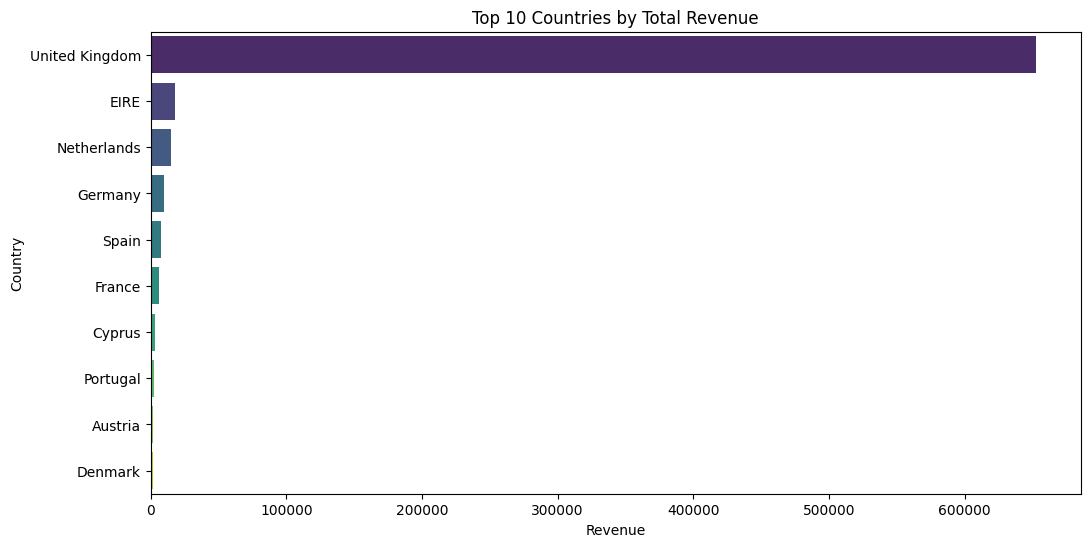

In [19]:
# Calculate Total Price
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['Price']

# Top 10 Countries by Revenue
top_countries = df_cleaned.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.show()

## 3. Time Series Analysis
Understanding sales trends over time is crucial for business planning. Let's look at monthly revenue.

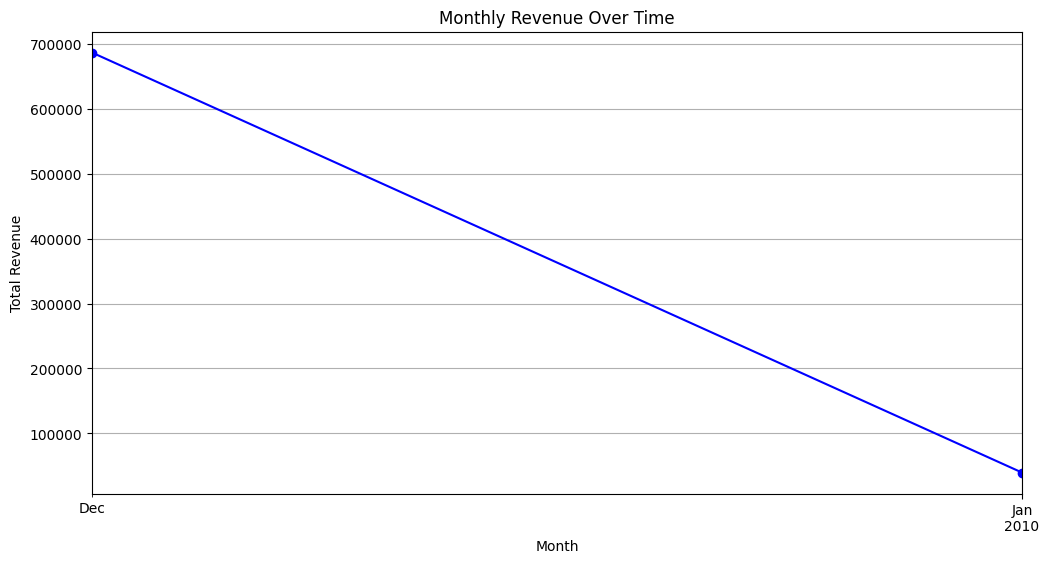

In [5]:
# Resample to monthly revenue
monthly_revenue = df_cleaned.set_index('InvoiceDate')['TotalPrice'].resample('ME').sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='b')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

## 4. Product Analysis
Which products are the most popular based on quantity sold?

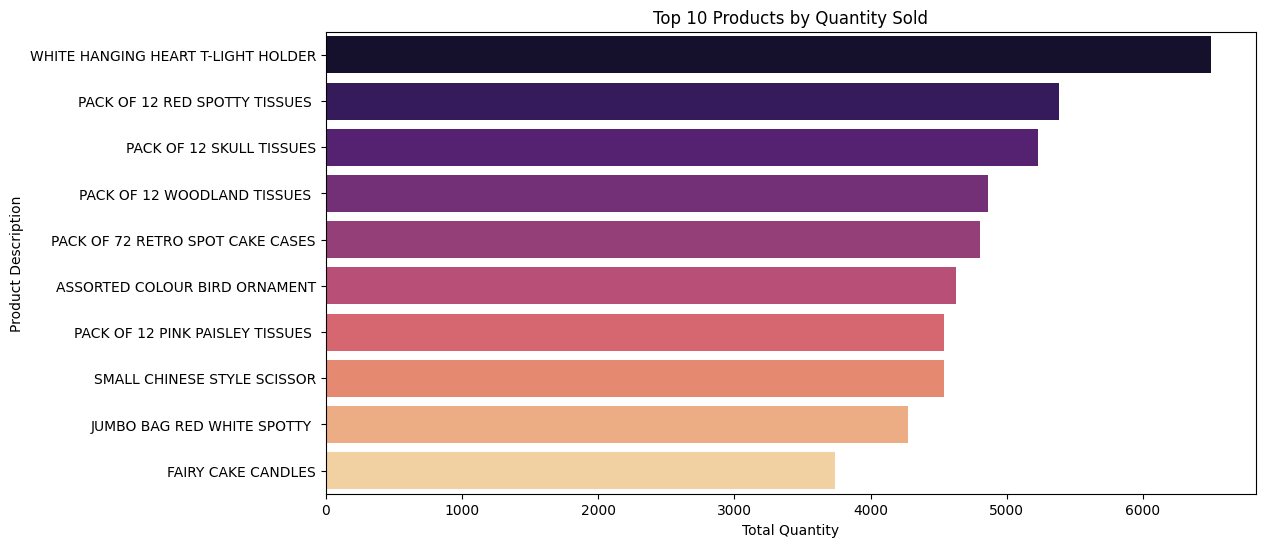

In [6]:
# Top 10 Products by Quantity
top_products = df_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='magma', legend=False)
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Product Description')
plt.show()

## 5. Customer Segmentation (RFM Analysis)
RFM analysis is a marketing technique used to quantitatively rank and group customers based on the recency, frequency, and monetary total of their recent transactions to identify the best customers and perform targeted marketing campaigns.

In [20]:
import datetime as dt

# 1. Establish an analytical snapshot date (1 day after the very last transaction)
snapshot_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Group transactions at the unique Customer ID level
rfm = df_cleaned.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency (Days since last order)
    'Invoice': 'nunique',                                    # Frequency (Total orders)
    'TotalPrice': 'sum'                                      # Monetary Value (Total spend)
})

# Rename columns for clarity
rfm.rename(columns={'InvoiceDate': 'Recency', 'Invoice': 'Frequency', 'TotalPrice': 'Monetary'}, inplace=True)

# 3. Create Quintile Scores (1 to 5) for each metric
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])  # Lower recency is better (5)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Calculate total composite score
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# 4. Map scores to strategic marketing labels
def assign_segment(row):
    score = row['RFM_Score']
    if score >= 13:
        return 'Champions / Loyal Customers'
    elif 9 <= score < 13:
        return 'Promising / Potential Loyalists'
    elif 6 <= score < 9:
        return 'Needs Attention / About to Sleep'
    else:
        return 'At Risk / Hibernating / Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# 5. Display the count of customers in each tier
print("--- Customer Value Segments ---")
print(rfm['Segment'].value_counts())

--- Customer Value Segments ---
Segment
Needs Attention / About to Sleep    349
Promising / Potential Loyalists     312
Champions / Loyal Customers         191
At Risk / Hibernating / Lost        128
Name: count, dtype: int64


## 6. Visualizing Customer Segments
Now we map the RFM scores to human-readable segments to see the distribution of our customer base.

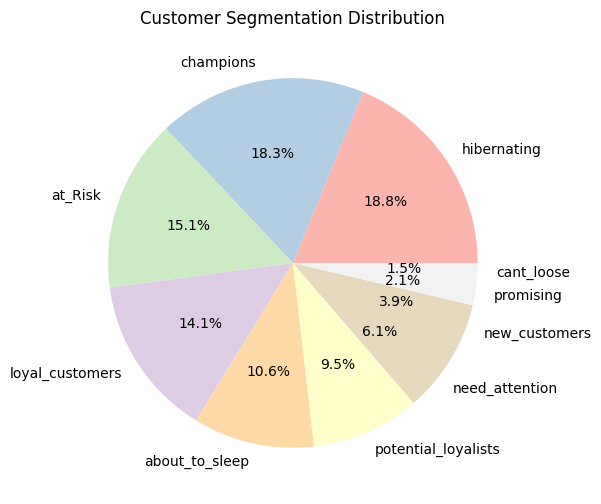

In [8]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

plt.figure(figsize=(12, 6))
rfm['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Customer Segmentation Distribution')
plt.ylabel('')
plt.show()

## 5. Customer Segmentation (RFM Analysis)
RFM analysis is a marketing technique used to quantitatively rank and group customers based on the recency, frequency, and monetary total of their recent transactions to identify the best customers and perform targeted marketing campaigns.

In [9]:
import datetime as dt

# Set the reference date for recency calculation (one day after the last invoice)
today_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM Table
rfm = df_cleaned.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,
    'Invoice': lambda x: x.nunique(),
    'TotalPrice': lambda x: x.sum()
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Score from 1 to 5 (5 is best)
rfm["recency_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm["frequency_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["monetary_score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores
rfm["RFM_SCORE"] = (rfm['recency_score'].astype(str) + rfm['frequency_score'].astype(str))

display(rfm.head())

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
Customer ID,,,,,,,
12346.0,3,7,158.50,5,5,1,55
12358.0,30,1,1429.83,2,1,5,21
12359.0,21,2,838.89,5,4,5,54
12362.0,37,1,130.00,1,1,1,11
12417.0,28,2,317.60,3,4,3,34


## 6. Visualizing Customer Segments
Now we map the RFM scores to human-readable segments to see the distribution of our customer base.

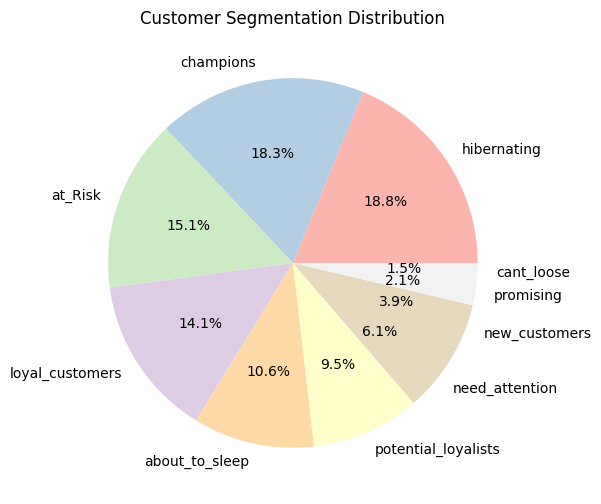

In [10]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

plt.figure(figsize=(12, 6))
rfm['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Customer Segmentation Distribution')
plt.ylabel('')
plt.show()

## 5. Customer Segmentation (RFM Analysis)
RFM analysis is a marketing technique used to quantitatively rank and group customers based on the recency, frequency and monetary total of their recent transactions to identify the best customers and perform targeted marketing campaigns.

In [11]:
import datetime as dt

# Set the reference date for recency calculation (one day after the last invoice)
today_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM Table
rfm = df_cleaned.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,
    'Invoice': lambda x: x.nunique(),
    'TotalPrice': lambda x: x.sum()
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Score from 1 to 5 (5 is best)
rfm["recency_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm["frequency_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["monetary_score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores
rfm["RFM_SCORE"] = (rfm['recency_score'].astype(str) + rfm['frequency_score'].astype(str))

display(rfm.head())

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
Customer ID,,,,,,,
12346.0,3,7,158.50,5,5,1,55
12358.0,30,1,1429.83,2,1,5,21
12359.0,21,2,838.89,5,4,5,54
12362.0,37,1,130.00,1,1,1,11
12417.0,28,2,317.60,3,4,3,34


## 6. Visualizing Customer Segments
Now we map the RFM scores to human-readable segments.

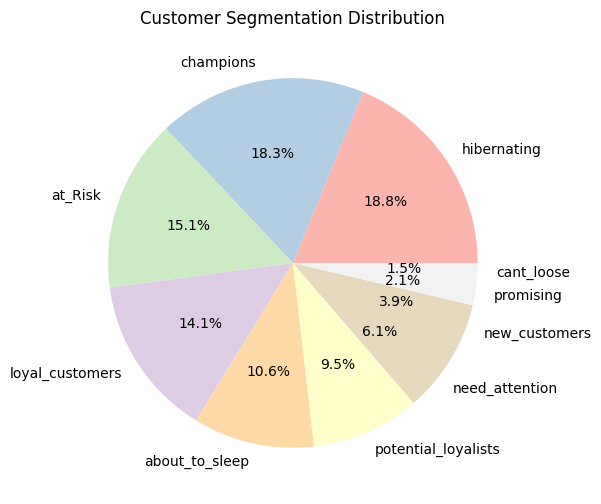

In [12]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

plt.figure(figsize=(12, 6))
rfm['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Customer Segmentation Distribution')
plt.ylabel('')
plt.show()

## 5. Customer Segmentation (RFM Analysis)
RFM analysis is a marketing technique used to quantitatively rank and group customers based on the recency, frequency and monetary total of their recent transactions to identify the best customers and perform targeted marketing campaigns.

In [13]:
import datetime as dt

# Set the reference date for recency calculation (one day after the last invoice)
today_date = df_cleaned['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM Table
rfm = df_cleaned.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,
    'Invoice': lambda x: x.nunique(),
    'TotalPrice': lambda x: x.sum()
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Score from 1 to 5 (5 is best)
rfm["recency_score"] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm["frequency_score"] = pd.qcut(rfm['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["monetary_score"] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Combine scores
rfm["RFM_SCORE"] = (rfm['recency_score'].astype(str) + rfm['frequency_score'].astype(str))

display(rfm.head())

,Recency,Frequency,Monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
Customer ID,,,,,,,
12346.0,3,7,158.50,5,5,1,55
12358.0,30,1,1429.83,2,1,5,21
12359.0,21,2,838.89,5,4,5,54
12362.0,37,1,130.00,1,1,1,11
12417.0,28,2,317.60,3,4,3,34


## 6. Visualizing Customer Segments
Now we map the RFM scores to human-readable segments.

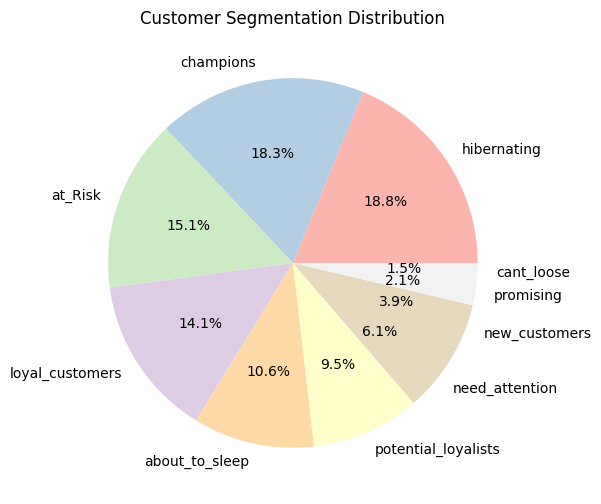

In [14]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

plt.figure(figsize=(12, 6))
rfm['segment'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Customer Segmentation Distribution')
plt.ylabel('')
plt.show()

## 3. Time Series Analysis
Understanding sales trends over time is crucial for business planning. Let's look at monthly revenue.

/tmp/ipykernel_3142/3994632919.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df_cleaned.set_index('InvoiceDate')['TotalPrice'].resample('M').sum()


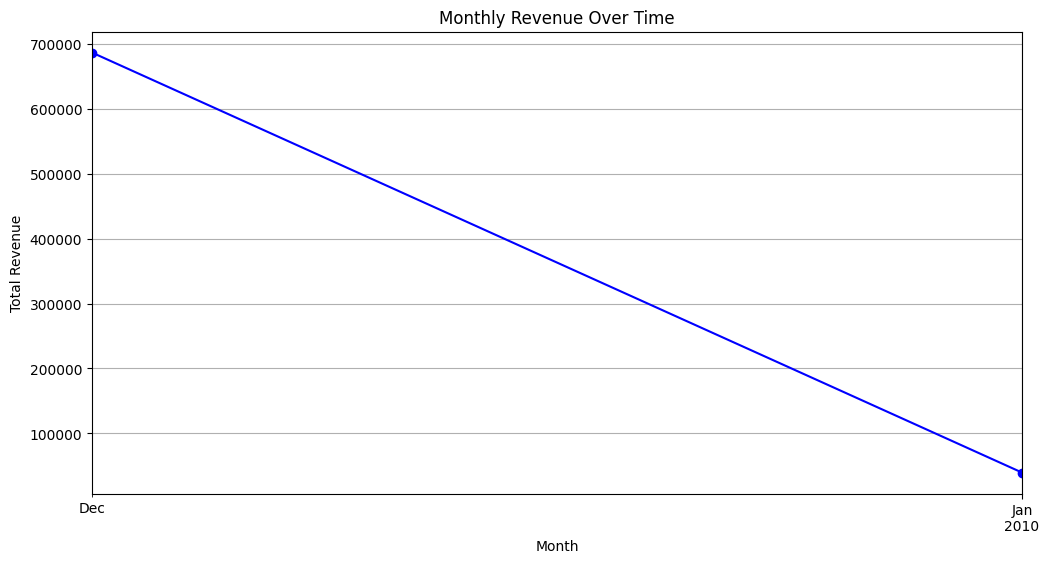

In [15]:
# Resample to monthly revenue
monthly_revenue = df_cleaned.set_index('InvoiceDate')['TotalPrice'].resample('M').sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='b')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

## 4. Product Analysis
Which products are the most popular based on quantity sold?

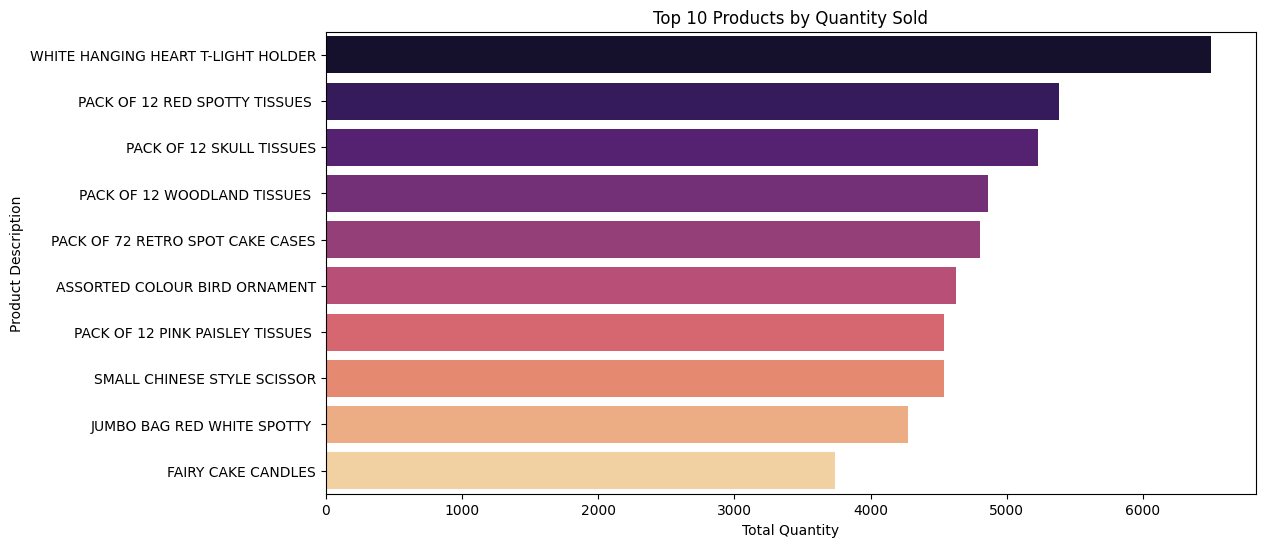

In [16]:
# Top 10 Products by Quantity
top_products = df_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='magma', legend=False)
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Product Description')
plt.show()

## 7. Fixing the Timeframe (Step 1)
To avoid misleading trends in our time-series analysis, we should remove the final month if it contains incomplete data. Let's check the date range and filter accordingly.

In [17]:
# Check the maximum date in the dataset
max_date = df_cleaned['InvoiceDate'].max()
print(f"Latest date in dataset: {max_date}")

# Filter out the incomplete month (December 2011)
# We'll keep data only up to November 2011 for consistent monthly comparisons
df_filtered = df_cleaned[df_cleaned['InvoiceDate'] < '2011-12-01']

print(f"New shape after filtering incomplete month: {df_filtered.shape}")

Latest date in dataset: 2010-01-06 14:54:00
New shape after filtering incomplete month: (32543, 9)


## 8. Customer Retention (Step 2: Cohort Analysis)
Cohort analysis allows us to see how well we retain customers over time based on their first purchase month.

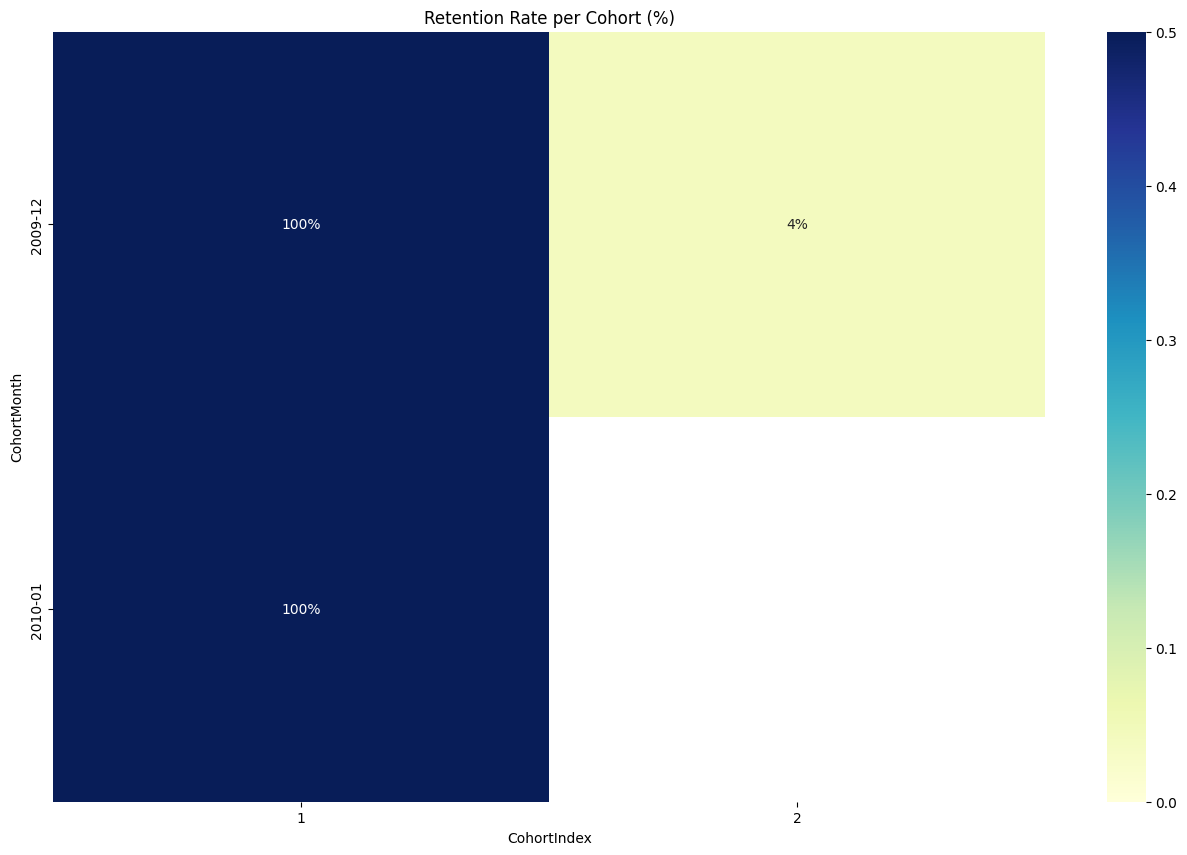

In [18]:
def get_month(x): return dt.datetime(x.year, x.month, 1)

# Create InvoiceMonth and CohortMonth
df_filtered['InvoiceMonth'] = df_filtered['InvoiceDate'].apply(get_month)
grouping = df_filtered.groupby('Customer ID')['InvoiceMonth']
df_filtered['CohortMonth'] = grouping.transform('min')

# Calculate time offset in months
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df_filtered, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df_filtered, 'CohortMonth')

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

df_filtered['CohortIndex'] = years_diff * 12 + months_diff + 1

# Count active customers from each cohort
cohort_data = df_filtered.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].apply(pd.Series.nunique).reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Calculate Retention Rate
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.strftime('%Y-%m')

# Visualize
plt.figure(figsize=(16, 10))
plt.title('Retention Rate per Cohort (%)')
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=0.5)
plt.show()

## 9. RFM Segmentation (Step 3)
Finally, we will create a granular RFM model. This involves calculating how recently a customer shopped, how often they buy, and their total spend, then scoring them to define their loyalty segment.

Top 10 Customers Segmented:


,Recency,Frequency,Monetary,Segment
Customer ID,,,,
12346.000000,3,7,$158.50,Champions
12358.000000,30,1,"$1,429.83",Hibernating
12359.000000,21,2,$838.89,Champions
12362.000000,37,1,$130.00,Hibernating
12417.000000,28,2,$317.60,Loyal Customers
12422.000000,20,1,$75.00,New Customers
12435.000000,36,1,"$1,008.00",Hibernating
12437.000000,35,1,$578.28,Hibernating
12439.000000,24,1,"$1,081.66",About to Sleep



Segment Statistics Summary:


Recency Frequency Monetary      
                       mean      mean     mean count
Segment                                             
About to Sleep         27.0       1.0    416.0   104
At Risk                33.7       1.1    360.7   148
Can't Lose             32.7       3.1    958.1    15
Champions              14.6       3.2   1857.9   179
Hibernating            33.4       1.0    373.6   184
Loyal Customers        24.6       2.1    930.4   138
Need Attention         27.0       1.0    374.4    60
New Customers          16.5       1.0    452.7    38
Potential Loyalists    18.4       1.0    419.4    93
Promising              22.4       1.0    333.2    21

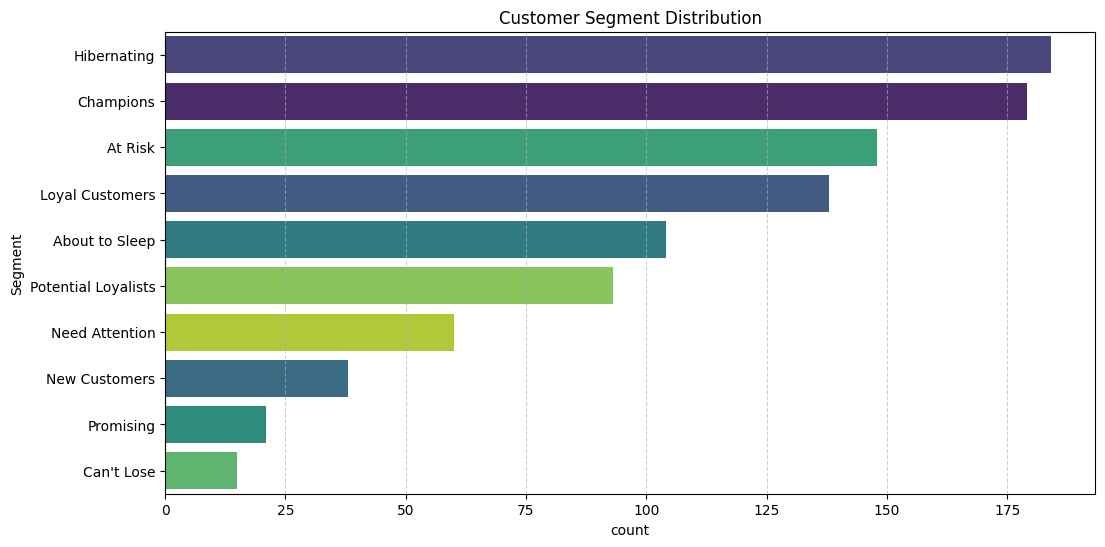

In [21]:
# 1. Calculate RFM Metrics
today_date = df_filtered['InvoiceDate'].max() + dt.timedelta(days=1)

rfm_final = df_filtered.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (today_date - x.max()).days,
    'Invoice': lambda x: x.nunique(),
    'TotalPrice': lambda x: x.sum()
})

rfm_final.columns = ['Recency', 'Frequency', 'Monetary']

# 2. Assign Scores (1-5)
rfm_final["R"] = pd.qcut(rfm_final['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm_final["F"] = pd.qcut(rfm_final['Frequency'].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm_final["M"] = pd.qcut(rfm_final['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 3. Create RFM Segment Strings
rfm_final['RFM_Segment'] = rfm_final['R'].astype(str) + rfm_final['F'].astype(str)

# 4. Map Segments to Business Labels
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm_final['Segment'] = rfm_final['RFM_Segment'].replace(seg_map, regex=True)

# --- IMPROVED OUTPUT TABLE ---
# Display the top 10 customers with conditional formatting
styled_rfm = rfm_final[['Recency', 'Frequency', 'Monetary', 'Segment']].head(10).style \
    .background_gradient(subset=['Recency'], cmap='RdYlGn_r') \
    .background_gradient(subset=['Frequency'], cmap='RdYlGn') \
    .background_gradient(subset=['Monetary'], cmap='RdYlGn') \
    .format({'Monetary': '${:,.2f}'})

print("Top 10 Customers Segmented:")
display(styled_rfm)

# Summary Table of Segments
segment_summary = rfm_final.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print("\nSegment Statistics Summary:")
display(segment_summary)

# Plot the segment distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=rfm_final, y='Segment', hue='Segment', palette='viridis', order=rfm_final['Segment'].value_counts().index, legend=False)
plt.title('Customer Segment Distribution')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()